# Notebook 7 : Multimodal Fusion QuantFormer

## Objective

This notebook extends the original QuantFormer architecture by
integrating Financial News embeddings generated using FinBERT with
Limit Order Book (LOB) features from the FI-2010 dataset.

The multimodal architecture combines:

- Limit Order Book Features
- Financial News Embeddings
- Fusion Layer
- Temporal Fusion Transformer

to improve short-term stock price movement prediction.

---

## Pipeline

Financial News
      │
      ▼
   FinBERT
      │
      ▼
News Embedding (768)

LOB Sequence
(100 × 143)
      │
      ▼
Input Projection
      │
      ▼
LSTM Encoder
      │
      ▼
Fusion Layer
      │
      ▼
Temporal Fusion Transformer
      │
      ▼
Classifier
      │
      ▼
Down / Stable / Up

In [ ]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print("QuantFormer Multimodal Fusion Notebook")

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device : {DEVICE}")


SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random Seed : {SEED}")


PROJECT_ROOT = Path.cwd().parent

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

CHECKPOINT_DIR.mkdir(exist_ok=True)

print(f"Project Root : {PROJECT_ROOT}")
print(f"Checkpoint Directory : {CHECKPOINT_DIR}")
# ============================================================
# Section 2 : Load Pretrained TFT Model
# ============================================================

from src.models.tft_model import QuantFormerTFT

# ------------------------------------------------------------
# Model Configuration
# ------------------------------------------------------------

INPUT_SIZE = 143
HIDDEN_SIZE = 128
NUM_HEADS = 4
DROPOUT = 0.20
NUM_CLASSES = 3

# ------------------------------------------------------------
# Initialize Model
# ------------------------------------------------------------

tft_model = QuantFormerTFT(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_heads=NUM_HEADS,
    dropout=DROPOUT,
    num_classes=NUM_CLASSES
)

# ------------------------------------------------------------
# Load Trained Weights
# ------------------------------------------------------------

CHECKPOINT_PATH = (
    CHECKPOINT_DIR /
    "best_tft_model.pth"
)

print("=" * 60)
print("Loading pretrained TFT checkpoint from:")
print(CHECKPOINT_PATH)
print("=" * 60)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)

# ------------------------------------------------------------
# Support Both Checkpoint Formats
# ------------------------------------------------------------

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:

    tft_model.load_state_dict(
        checkpoint["model_state_dict"]
    )

else:

    tft_model.load_state_dict(checkpoint)

# ------------------------------------------------------------
# Evaluation Mode
# ------------------------------------------------------------

tft_model = tft_model.to(DEVICE)
tft_model.eval()

print("✓ TFT Model Loaded Successfully")
print("=" * 60)

QuantFormer Multimodal Fusion Notebook
Device : cpu
Random Seed : 42
Project Root : d:\Coding\Quant Former
Checkpoint Directory : d:\Coding\Quant Former\checkpoints


c:\Users\gupta\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ============================================================
# Add Project Root to Python Path
# ============================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project Root :", PROJECT_ROOT)



Project Root : d:\Coding\Quant Former


In [13]:
# ============================================================
# Section 2 : Load Pretrained Temporal Fusion Transformer
# ============================================================

from pathlib import Path
import torch

from src.models.tft_model import TemporalFusionTransformer

# ------------------------------------------------------------
# Initialize TFT Model
# ------------------------------------------------------------

print("=" * 60)
print("Initializing Temporal Fusion Transformer...")
print("=" * 60)

tft_model = TemporalFusionTransformer()

# ------------------------------------------------------------
# Checkpoint Path
# ------------------------------------------------------------

CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "best_tft_model.pth"
)

print("Checkpoint Path:")
print(CHECKPOINT_PATH)

# ------------------------------------------------------------
# Load Checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)

# ------------------------------------------------------------
# Load Model Weights
# ------------------------------------------------------------

if isinstance(checkpoint, dict):

    if "model_state_dict" in checkpoint:

        tft_model.load_state_dict(
            checkpoint["model_state_dict"]
        )

    elif "state_dict" in checkpoint:

        tft_model.load_state_dict(
            checkpoint["state_dict"]
        )

    else:

        tft_model.load_state_dict(
            checkpoint
        )

else:

    tft_model.load_state_dict(
        checkpoint
    )

# ------------------------------------------------------------
# Move Model to Device
# ------------------------------------------------------------

tft_model = tft_model.to(DEVICE)

# ------------------------------------------------------------
# Evaluation Mode
# ------------------------------------------------------------

tft_model.eval()

print()
print("=" * 60)
print("✓ Pretrained TFT Model Loaded Successfully")
print("=" * 60)

Initializing Temporal Fusion Transformer...
Checkpoint Path:
d:\Coding\Quant Former\checkpoints\best_tft_model.pth

✓ Pretrained TFT Model Loaded Successfully


In [14]:
print(tft_model)

TemporalFusionTransformer(
  (input_projection): InputProjection(
    (projection): Linear(in_features=143, out_features=128, bias=True)
  )
  (position_encoding): PositionalEncoding()
  (encoder): LSTMEncoder(
    (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.2)
  )
  (grn): GatedResidualNetwork(
    (fc1): Linear(in_features=128, out_features=128, bias=True)
    (activation): ELU(alpha=1.0)
    (fc2): Linear(in_features=128, out_features=128, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
    (skip): Identity()
    (gate_add_norm): GateAddNorm(
      (glu): GLU(
        (linear): Linear(in_features=128, out_features=128, bias=True)
        (gate): Linear(in_features=128, out_features=128, bias=True)
      )
      (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    )
  )
  (attention): InterpretableMultiHeadAttention(
    (query): Linear(in_features=128, out_features=128, bias=True)
    (key): Linear(in_features=128, out_featu

In [15]:
# ============================================================
# Model Statistics
# ============================================================

total_params = sum(
    p.numel()
    for p in tft_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in tft_model.parameters()
    if p.requires_grad
)

print("=" * 60)
print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print("=" * 60)

Total Parameters     : 654,723
Trainable Parameters : 654,723


In [16]:
# ============================================================
# Section 3 : Load Pretrained FinBERT
# ============================================================

from transformers import AutoTokenizer, AutoModel

# ------------------------------------------------------------
# FinBERT Configuration
# ------------------------------------------------------------

MODEL_NAME = "ProsusAI/finbert"

print("Loading Pretrained FinBERT...")

# ------------------------------------------------------------
# Load Tokenizer
# ------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

# ------------------------------------------------------------
# Load Model
# ------------------------------------------------------------

finbert_model = AutoModel.from_pretrained(
    MODEL_NAME
)

# ------------------------------------------------------------
# Move to Device
# ------------------------------------------------------------

finbert_model = finbert_model.to(DEVICE)

# ------------------------------------------------------------
# Evaluation Mode
# ------------------------------------------------------------

finbert_model.eval()

print("✓ FinBERT Loaded Successfully")


Loading Pretrained FinBERT...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 22119.16it/s]
[transformers] BertModel LOAD REPORT from: ProsusAI/finbert
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ FinBERT Loaded Successfully


In [17]:
print(finbert_model)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
            (dropout): Dropout(p=

In [19]:
# ============================================================
# FinBERT Statistics
# ============================================================

total_params = sum(
    p.numel()
    for p in finbert_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in finbert_model.parameters()
    if p.requires_grad
)

print("=" * 60)
print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print("=" * 60)

Total Parameters     : 109,482,240
Trainable Parameters : 109,482,240


In [20]:
# ============================================================
# Generate Sample Embedding
# ============================================================

sample_text = (
    "Apple stock rises after reporting strong quarterly earnings."
)

inputs = tokenizer(
    sample_text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

inputs = {
    key: value.to(DEVICE)
    for key, value in inputs.items()
}

with torch.no_grad():

    outputs = finbert_model(**inputs)

embedding = outputs.last_hidden_state.mean(dim=1)

print("=" * 60)
print("Embedding Shape :", embedding.shape)
print("=" * 60)

Embedding Shape : torch.Size([1, 768])


In [21]:
# ============================================================
# Section 4 : Freeze Pretrained Models
# ============================================================

print("=" * 60)
print("Freezing Pretrained Models...")
print("=" * 60)

# ------------------------------------------------------------
# Freeze TFT
# ------------------------------------------------------------

for param in tft_model.parameters():
    param.requires_grad = False

# ------------------------------------------------------------
# Freeze FinBERT
# ------------------------------------------------------------

for param in finbert_model.parameters():
    param.requires_grad = False

# ------------------------------------------------------------
# Keep Models in Evaluation Mode
# ------------------------------------------------------------

tft_model.eval()
finbert_model.eval()

print("✓ TFT Frozen")
print("✓ FinBERT Frozen")
print("=" * 60)

Freezing Pretrained Models...
✓ TFT Frozen
✓ FinBERT Frozen


In [22]:
# ============================================================
# Verify Frozen Parameters
# ============================================================

tft_trainable = sum(
    p.numel()
    for p in tft_model.parameters()
    if p.requires_grad
)

finbert_trainable = sum(
    p.numel()
    for p in finbert_model.parameters()
    if p.requires_grad
)

print("=" * 60)
print(f"TFT Trainable Parameters      : {tft_trainable:,}")
print(f"FinBERT Trainable Parameters  : {finbert_trainable:,}")
print("=" * 60)

TFT Trainable Parameters      : 0
FinBERT Trainable Parameters  : 0


## Observation

Both pretrained models were successfully frozen by setting
`requires_grad = False` for every parameter.

Freezing the models ensures that:

- The pretrained knowledge learned by the Temporal Fusion Transformer
  remains unchanged.
- FinBERT continues to generate high-quality financial language
  representations without additional fine-tuning.
- During training, gradients will be computed only for the Multimodal
  Fusion Network, reducing computational cost and preventing
  catastrophic forgetting.

This architecture follows the standard transfer learning strategy
where pretrained encoders are used as fixed feature extractors while
only the downstream fusion layers are optimized.

# Section 5 : Multimodal Fusion Network

In this section, we build the proposed **QuantFormer Multimodal Fusion Network**.

The architecture combines two pretrained feature extractors:

- Temporal Fusion Transformer (TFT) for learning temporal market dynamics.
- FinBERT for extracting semantic representations from financial news.

Instead of training both models again, they remain frozen and only provide high-level representations.

The extracted features are projected into a common latent space and fused through a learnable multimodal fusion block. The fused representation is then passed through fully connected layers to predict the future market movement into one of three classes:

- Down
- Stable
- Up

This architecture enables QuantFormer to jointly learn from numerical market data and textual financial sentiment.

In [23]:
import torch
import torch.nn as nn

In [24]:
class FeatureProjection(nn.Module):
    """
    Projects feature vectors into a common latent space.
    """

    def __init__(
        self,
        input_dim,
        hidden_dim
    ):

        super().__init__()

        self.projection = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Dropout(0.2)

        )

    def forward(self, x):

        return self.projection(x)

In [25]:
class QuantFormerFusion(nn.Module):

    def __init__(self):

        super().__init__()

        # ----------------------------------------------
        # Projection Layers
        # ----------------------------------------------

        self.market_projection = FeatureProjection(
            input_dim=128,
            hidden_dim=256
        )

        self.news_projection = FeatureProjection(
            input_dim=768,
            hidden_dim=256
        )

        # ----------------------------------------------
        # Fusion Layer
        # ----------------------------------------------

        self.fusion = nn.Sequential(

            nn.Linear(
                512,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.30)

        )

        # ----------------------------------------------
        # Classifier
        # ----------------------------------------------

        self.classifier = nn.Sequential(

            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.30),

            nn.Linear(
                128,
                3
            )

        )

    def forward(
        self,
        market_features,
        news_features
    ):

        market = self.market_projection(
            market_features
        )

        news = self.news_projection(
            news_features
        )

        fused = torch.cat(
            [
                market,
                news
            ],
            dim=1
        )

        fused = self.fusion(
            fused
        )

        output = self.classifier(
            fused
        )

        return output

In [26]:
# ============================================================
# Initialize Fusion Model
# ============================================================

fusion_model = QuantFormerFusion().to(DEVICE)

print("=" * 60)
print("QuantFormer Fusion Network Created Successfully")
print("=" * 60)

QuantFormer Fusion Network Created Successfully


In [27]:
print(fusion_model)

QuantFormerFusion(
  (market_projection): FeatureProjection(
    (projection): Sequential(
      (0): Linear(in_features=128, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
    )
  )
  (news_projection): FeatureProjection(
    (projection): Sequential(
      (0): Linear(in_features=768, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
    )
  )
  (fusion): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


In [28]:
# ============================================================
# Count Trainable Parameters
# ============================================================

total_params = sum(
    p.numel()
    for p in fusion_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in fusion_model.parameters()
    if p.requires_grad
)

print("=" * 60)
print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print("=" * 60)

Total Parameters     : 394,499
Trainable Parameters : 394,499


## Observation

The Multimodal Fusion Network was successfully initialized.

The architecture consists of three major components:

1. **Market Feature Projection**
   - Projects the Temporal Fusion Transformer output into a shared latent representation.

2. **News Feature Projection**
   - Projects the FinBERT sentence embedding into the same latent space.

3. **Fusion Classifier**
   - Concatenates both projected representations and learns a joint feature representation for predicting future market movement.

Unlike the pretrained TFT and FinBERT models, all parameters of the Fusion Network remain trainable. During optimization, only this network will learn while the pretrained encoders remain frozen.

In [29]:
print(tft_model)

TemporalFusionTransformer(
  (input_projection): InputProjection(
    (projection): Linear(in_features=143, out_features=128, bias=True)
  )
  (position_encoding): PositionalEncoding()
  (encoder): LSTMEncoder(
    (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.2)
  )
  (grn): GatedResidualNetwork(
    (fc1): Linear(in_features=128, out_features=128, bias=True)
    (activation): ELU(alpha=1.0)
    (fc2): Linear(in_features=128, out_features=128, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
    (skip): Identity()
    (gate_add_norm): GateAddNorm(
      (glu): GLU(
        (linear): Linear(in_features=128, out_features=128, bias=True)
        (gate): Linear(in_features=128, out_features=128, bias=True)
      )
      (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    )
  )
  (attention): InterpretableMultiHeadAttention(
    (query): Linear(in_features=128, out_features=128, bias=True)
    (key): Linear(in_features=128, out_featu

# Section 4 - Load Pretrained QuantFormer Checkpoint

In this section we load the pretrained Temporal Fusion Transformer
that was trained in Notebook 6.

The trained weights are restored into the model.

This allows us to use the exact trained market encoder
instead of an untrained network.

The model is then switched to evaluation mode
because Notebook 7 performs inference only.

In [30]:
from pathlib import Path
import torch

PROJECT_ROOT = Path.cwd().parent

CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "best_tft_model.pth"
)

print(CHECKPOINT_PATH)

d:\Coding\Quant Former\checkpoints\best_tft_model.pth


In [31]:
assert CHECKPOINT_PATH.exists(), "Checkpoint file not found!"

print("Checkpoint Found ✓")

Checkpoint Found ✓


In [32]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)

print(type(checkpoint))

<class 'dict'>


In [33]:
checkpoint.keys()

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'best_validation_accuracy'])

In [34]:
checkpoint.keys()

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'best_validation_accuracy'])

### Observation

- The pretrained checkpoint was successfully located.
- The checkpoint has been loaded into memory.
- The checkpoint structure was inspected before loading.
- This ensures compatibility between the saved weights and the model architecture.

In [36]:
%whos

Variable                    Type                                            Data/Info
-------------------------------------------------------------------------------------
AutoModel                   type                                            <class 'transformers.mode<...>modeling_auto.AutoModel'>
AutoTokenizer               type                                            <class 'transformers.mode<...>tion_auto.AutoTokenizer'>
CHECKPOINT_DIR              WindowsPath                                     d:\Coding\Quant Former\checkpoints
CHECKPOINT_PATH             WindowsPath                                     d:\Coding\Quant Former\ch<...>points\best_tft_model.pth
DEVICE                      device                                          cpu
DataLoader                  type                                            <class 'torch.utils.data.dataloader.DataLoader'>
Dataset                     type                                            <class 'torch.utils.data.dataset.Dataset

In [37]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'os', 'random', 'warnings', 'Path', 'np', 'pd', 'torch', 'nn', 'Dataset', 'DataLoader', 'train_test_split', 'accuracy_score', 'precision_score', 'recall_score', 'f1_score', 'classification_report', 'confusion_matrix', 'tqdm', 'DEVICE', 'SEED', 'PROJECT_ROOT', 'CHECKPOINT_DIR', '_i2', '_i3', '_i4', 'sys', '_i5', '_i6', 'FI2010Dataset', 'TemporalFusionTransformer', 'evaluate_predictions', '_i7', '_i8', '_i9', '_i10', 'inspect', 'tft_model', '_i11', 'name', 'obj', '_i12', '_i13', 'CHECKPOINT_PATH', 'checkpoint', '_i14', '_i15', 'total_params', 'trainable_params', '_i16', 'AutoTokenizer', 'AutoModel', 'MODEL_NAME', 'tokenizer', 'finbert_model', '_i17', '_i18', '_18', '_i19', '_i20', 'sample_text', 'inputs', 'outputs', 'embedding', '_i21', 'param',

In [38]:
print(type(tft_model))

<class 'src.models.tft_model.TemporalFusionTransformer'>


In [39]:
tft_model.load_state_dict(
    checkpoint["model_state_dict"]
)

tft_model.to(DEVICE)
tft_model.eval()

print("✓ QuantFormer checkpoint loaded successfully.")

✓ QuantFormer checkpoint loaded successfully.


In [40]:
# ==========================================================
# Fusion Model Configuration
# ==========================================================

FUSION_INPUT_DIM = 128 + 128      # TFT + Projected FinBERT
FUSION_HIDDEN_DIM = 256

NUM_CLASSES = 3

print("=" * 60)
print("Fusion Configuration")
print("=" * 60)

print(f"TFT Feature Size          : 128")
print(f"FinBERT Feature Size      : 768")
print(f"Projected Feature Size    : 128")
print(f"Fusion Input Dimension    : {FUSION_INPUT_DIM}")
print(f"Fusion Hidden Dimension   : {FUSION_HIDDEN_DIM}")
print(f"Output Classes            : {NUM_CLASSES}")

Fusion Configuration
TFT Feature Size          : 128
FinBERT Feature Size      : 768
Projected Feature Size    : 128
Fusion Input Dimension    : 256
Fusion Hidden Dimension   : 256
Output Classes            : 3


In [42]:
tft_model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Model weights loaded successfully.")

Model weights loaded successfully.


In [43]:
tft_model.to(DEVICE)
tft_model.eval()

TemporalFusionTransformer(
  (input_projection): InputProjection(
    (projection): Linear(in_features=143, out_features=128, bias=True)
  )
  (position_encoding): PositionalEncoding()
  (encoder): LSTMEncoder(
    (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.2)
  )
  (grn): GatedResidualNetwork(
    (fc1): Linear(in_features=128, out_features=128, bias=True)
    (activation): ELU(alpha=1.0)
    (fc2): Linear(in_features=128, out_features=128, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
    (skip): Identity()
    (gate_add_norm): GateAddNorm(
      (glu): GLU(
        (linear): Linear(in_features=128, out_features=128, bias=True)
        (gate): Linear(in_features=128, out_features=128, bias=True)
      )
      (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    )
  )
  (attention): InterpretableMultiHeadAttention(
    (query): Linear(in_features=128, out_features=128, bias=True)
    (key): Linear(in_features=128, out_featu

In [44]:
tft_model = tft_model.to(DEVICE)
tft_model.eval()

print(f"Model loaded on {DEVICE}")

Model loaded on cpu


In [45]:
print("=" * 60)
print("Pretrained QuantFormer Loaded Successfully")
print("=" * 60)

print(f"Training Epoch      : {checkpoint['epoch']}")
print(f"Best Validation Acc : {checkpoint['best_validation_accuracy']:.4f}")

print("=" * 60)

Pretrained QuantFormer Loaded Successfully
Training Epoch      : 15
Best Validation Acc : 0.8376


# Section 5 — Multimodal Fusion Network

## Objective

In this section, we construct the QuantFormer Fusion Network.

The model combines information from two different modalities:

- Market features extracted by the Temporal Fusion Transformer (TFT).
- Financial news embeddings generated by FinBERT.

The FinBERT embedding is projected into the same latent space as the TFT output before feature fusion.

The concatenated representation is passed through a fully connected classifier to predict the next market movement.

In [46]:
TFT_FEATURE_DIM = 128
FINBERT_DIM = 768
PROJECTED_DIM = 128

FUSION_DIM = TFT_FEATURE_DIM + PROJECTED_DIM

NUM_CLASSES = 3

print("=" * 60)
print("Fusion Configuration")
print("=" * 60)

print(f"TFT Feature Dimension      : {TFT_FEATURE_DIM}")
print(f"FinBERT Embedding          : {FINBERT_DIM}")
print(f"Projected Embedding        : {PROJECTED_DIM}")
print(f"Fusion Dimension           : {FUSION_DIM}")
print(f"Prediction Classes         : {NUM_CLASSES}")

Fusion Configuration
TFT Feature Dimension      : 128
FinBERT Embedding          : 768
Projected Embedding        : 128
Fusion Dimension           : 256
Prediction Classes         : 3


In [47]:
class FeatureProjection(nn.Module):
    """
    Projects FinBERT embedding
    from 768 dimensions to 128 dimensions.
    """

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(FINBERT_DIM, 256),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(256, PROJECTED_DIM)

        )

    def forward(self, x):

        return self.network(x)

In [48]:
class QuantFormerFusion(nn.Module):

    def __init__(self):

        super().__init__()

        self.feature_projection = FeatureProjection()

        self.classifier = nn.Sequential(

            nn.Linear(FUSION_DIM, 256),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(256,128),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(128,NUM_CLASSES)

        )

    def forward(
        self,
        tft_features,
        finbert_embedding
    ):

        projected_news = self.feature_projection(
            finbert_embedding
        )

        fused_features = torch.cat(

            [
                tft_features,
                projected_news
            ],

            dim=1

        )

        logits = self.classifier(
            fused_features
        )

        return logits

In [49]:
fusion_model = QuantFormerFusion().to(DEVICE)

print("=" * 60)
print("Fusion Model Created Successfully")
print("=" * 60)

print(fusion_model)

Fusion Model Created Successfully
QuantFormerFusion(
  (feature_projection): FeatureProjection(
    (network): Sequential(
      (0): Linear(in_features=768, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=256, out_features=128, bias=True)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=3, bias=True)
  )
)


In [50]:
total_params = sum(
    p.numel()
    for p in fusion_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in fusion_model.parameters()
    if p.requires_grad
)

print("=" * 60)
print("Fusion Model Statistics")
print("=" * 60)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Fusion Model Statistics
Total Parameters     : 328,835
Trainable Parameters : 328,835


In [52]:
dummy_tft = torch.randn(
    4,
    TFT_FEATURE_DIM
).to(DEVICE)

dummy_news = torch.randn(
    4,
    FINBERT_DIM
).to(DEVICE)

fusion_model.eval()

with torch.no_grad():

    output = fusion_model(
        dummy_tft,
        dummy_news
    )

print("Input Shape (TFT):", dummy_tft.shape)
print("Input Shape (News):", dummy_news.shape)
print("Output Shape:", output.shape)

Input Shape (TFT): torch.Size([4, 128])
Input Shape (News): torch.Size([4, 768])
Output Shape: torch.Size([4, 3])


## Observation

The QuantFormer Fusion Network was successfully implemented.

Key observations:

- TFT generates a 128-dimensional representation of market dynamics.
- FinBERT generates a 768-dimensional semantic embedding of financial news.
- A projection network reduces the FinBERT embedding to 128 dimensions.
- Both feature vectors are concatenated into a 256-dimensional multimodal representation.
- The classifier predicts one of three market movement classes: Down, Stable, or Up.
- A dummy forward pass confirms that the fusion model produces outputs with the expected shape `(batch_size, 3)`.

# Section 6 — End-to-End Multimodal Inference

## Objective

This section integrates every component of QuantFormer into a single inference pipeline.

Pipeline:

Market Sequence
        │
        ▼
Temporal Fusion Transformer
        │
   Market Features (128)

Financial News
        │
        ▼
FinBERT
        │
 News Embedding (768)

        ▼
Projection Layer
        │
        ▼
Feature Fusion
        │
        ▼
Prediction Head
        │
        ▼
Down / Stable / Up

In [53]:
LABELS = {
    0: "DOWN",
    1: "STABLE",
    2: "UP"
}

print(LABELS)

{0: 'DOWN', 1: 'STABLE', 2: 'UP'}


In [54]:
def get_news_embedding(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        k: v.to(DEVICE)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = finbert_model(**inputs)

    embedding = outputs.last_hidden_state.mean(dim=1)

    return embedding

In [55]:
import inspect

print(inspect.signature(tft_model.forward))

(x)


In [56]:
print(tft_model.forward)

<bound method TemporalFusionTransformer.forward of TemporalFusionTransformer(
  (input_projection): InputProjection(
    (projection): Linear(in_features=143, out_features=128, bias=True)
  )
  (position_encoding): PositionalEncoding()
  (encoder): LSTMEncoder(
    (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.2)
  )
  (grn): GatedResidualNetwork(
    (fc1): Linear(in_features=128, out_features=128, bias=True)
    (activation): ELU(alpha=1.0)
    (fc2): Linear(in_features=128, out_features=128, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
    (skip): Identity()
    (gate_add_norm): GateAddNorm(
      (glu): GLU(
        (linear): Linear(in_features=128, out_features=128, bias=True)
        (gate): Linear(in_features=128, out_features=128, bias=True)
      )
      (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    )
  )
  (attention): InterpretableMultiHeadAttention(
    (query): Linear(in_features=128, out_features=128, bias

In [57]:
import inspect

print(inspect.getsource(TemporalFusionTransformer.forward))

    def forward(self, x):
    


        x = self.input_projection(x)

        
        x = self.position_encoding(x)


        lstm_features = self.encoder(x)


        grn_features = self.grn(lstm_features)


        attention_features, attention_weights = self.attention(
            grn_features
        )

        refined_features = self.post_attention_grn(
            attention_features
        )


        refined_features = self.feed_forward(
            refined_features
        )


        fused_features = self.gate_norm(
            refined_features,
            grn_features
        )

        pooled_features = fused_features.mean(dim=1)

        logits = self.classifier(
            pooled_features
        )

        return logits, pooled_features, attention_weights



# Section 6 — End-to-End Inference Pipeline

## Objective

This section integrates all QuantFormer components into a single inference pipeline.

The pipeline performs:

1. Market sequence → Temporal Fusion Transformer
2. News headline → FinBERT
3. Extract pooled TFT representation
4. Generate FinBERT embedding
5. Fuse both representations
6. Predict market movement


In [58]:
LABELS = {
    0: "DOWN",
    1: "STABLE",
    2: "UP"
}

In [59]:
def generate_news_embedding(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        k: v.to(DEVICE)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = finbert_model(**inputs)

    embedding = outputs.last_hidden_state.mean(dim=1)

    return embedding

In [60]:
def extract_market_features(sequence):

    sequence = torch.tensor(
        sequence,
        dtype=torch.float32
    ).unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        logits, pooled_features, attention = tft_model(sequence)

    return logits, pooled_features, attention

In [61]:
def multimodal_prediction(
    market_sequence,
    news_text
):

    logits, market_features, attention = extract_market_features(
        market_sequence
    )

    news_embedding = generate_news_embedding(
        news_text
    )

    fusion_logits = fusion_model(
        market_features,
        news_embedding
    )

    probabilities = torch.softmax(
        fusion_logits,
        dim=1
    )

    confidence, prediction = torch.max(
        probabilities,
        dim=1
    )

    return {

        "prediction": LABELS[prediction.item()],

        "class_id": prediction.item(),

        "confidence": confidence.item(),

        "market_features": market_features,

        "news_embedding": news_embedding,

        "attention": attention

    }

In [62]:
dummy_market = np.random.randn(
    100,
    143
).astype(np.float32)

dummy_news = (
    "Apple reported better than expected quarterly earnings."
)

result = multimodal_prediction(
    dummy_market,
    dummy_news
)

print("=" * 60)
print("Multimodal Prediction")
print("=" * 60)

print("Prediction :", result["prediction"])
print("Confidence :", round(result["confidence"],4))

Multimodal Prediction
Prediction : UP
Confidence : 0.3574


## Observation

The complete multimodal inference pipeline was successfully integrated.

Key observations:

- The Temporal Fusion Transformer processes the FI-2010 market sequence and produces logits, pooled features, and attention weights.
- The pooled feature vector is used as the market representation.
- FinBERT converts the financial news headline into a 768-dimensional embedding.
- The fusion network combines market and news features to generate the final market movement prediction.
- Softmax converts the model outputs into prediction probabilities, and the highest probability determines the predicted class.

# Section 7 — Generate Market Embeddings

## Objective

In this section we generate the latent market representation from the
pretrained Temporal Fusion Transformer (TFT).

Instead of using the final class prediction directly, we extract the
intermediate pooled feature vector learned by the model.

These embeddings capture:

- Order book dynamics
- Price movement patterns
- Liquidity behaviour
- Temporal dependencies

These market embeddings will later be fused with FinBERT news embeddings
inside the QuantFormer Fusion Model.

In [68]:
import os

for root, dirs, files in os.walk(PROJECT_ROOT):
    for file in files:
        if "test" in file.lower():
            print(os.path.join(root, file))

d:\Coding\Quant Former\artifacts\test_predictions.csv
d:\Coding\Quant Former\datasets\FI2010\test.csv
d:\Coding\Quant Former\datasets\FI2010\test_clean.csv
d:\Coding\Quant Former\datasets\processed\FI2010\X_test.npy
d:\Coding\Quant Former\datasets\processed\FI2010\y_test.npy
d:\Coding\Quant Former\src\kafka\latest_news.py
d:\Coding\Quant Former\src\kafka\__pycache__\latest_news.cpython-312.pyc


In [69]:
print(PROJECT_ROOT)

d:\Coding\Quant Former


# Section 7 — Load FI-2010 Test Dataset

In this section we load the processed FI-2010 test dataset that was generated during the preprocessing stage.

The processed NumPy arrays are converted into a PyTorch Dataset and DataLoader for inference with the pretrained Temporal Fusion Transformer.

Output:
- X_test shape
- y_test shape
- Number of samples
- Test DataLoader

In [70]:
import numpy as np

X_TEST_PATH = PROJECT_ROOT / "datasets" / "processed" / "FI2010" / "X_test.npy"
Y_TEST_PATH = PROJECT_ROOT / "datasets" / "processed" / "FI2010" / "y_test.npy"

X_test = np.load(X_TEST_PATH)
y_test = np.load(Y_TEST_PATH)

print("=" * 60)
print("FI-2010 Test Dataset Loaded")
print("=" * 60)

print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)

FI-2010 Test Dataset Loaded
X_test Shape : (31838, 100, 143)
y_test Shape : (31838,)


In [71]:
test_dataset = FI2010Dataset(
    X_test,
    y_test
)

print("Dataset Size :", len(test_dataset))

Dataset Size : 31838


In [72]:
BATCH_SIZE = 64

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Number of Test Batches :", len(test_loader))

Number of Test Batches : 498


In [73]:
features, labels = next(iter(test_loader))

print("=" * 60)
print("One Test Batch")
print("=" * 60)

print("Features Shape :", features.shape)
print("Labels Shape   :", labels.shape)

One Test Batch
Features Shape : torch.Size([64, 100, 143])
Labels Shape   : torch.Size([64])


In [74]:
features = features.to(DEVICE)
labels = labels.to(DEVICE)

print("Features Device :", features.device)
print("Labels Device   :", labels.device)

Features Device : cpu
Labels Device   : cpu


## Observation

The processed FI-2010 dataset was successfully loaded from the NumPy files created during preprocessing.

The data was converted into a custom `FI2010Dataset` object and wrapped inside a PyTorch `DataLoader`, enabling efficient batch-wise inference.

Each input sample contains:

- Sequence Length = 100
- Feature Dimension = 143

The batch is now ready to be passed through the pretrained Temporal Fusion Transformer.

# Section 8 — Extract Market Features from Temporal Fusion Transformer

The pretrained Temporal Fusion Transformer is used as a feature extractor.

Instead of using the final classification output, we extract the intermediate pooled market representation.

Outputs:
- Market logits
- 128-dimensional pooled market embedding
- Attention weights

In [77]:
model = TemporalFusionTransformer()

print("=" * 60)
print("Temporal Fusion Transformer Created Successfully")
print("=" * 60)

Temporal Fusion Transformer Created Successfully


In [78]:
model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("✓ Pretrained TFT Weights Loaded")

✓ Pretrained TFT Weights Loaded


In [79]:
model = model.to(DEVICE)
model.eval()

print("Device :", DEVICE)

Device : cpu


In [80]:
print(type(model))

<class 'src.models.tft_model.TemporalFusionTransformer'>


In [81]:
model.eval()

with torch.no_grad():

    logits, market_features, attention_weights = model(features)

In [82]:
print("=" * 60)
print("Temporal Fusion Transformer Outputs")
print("=" * 60)

print("Classification Logits :", logits.shape)
print("Market Features       :", market_features.shape)
print("Attention Shape       :", attention_weights.shape)

Temporal Fusion Transformer Outputs
Classification Logits : torch.Size([64, 3])
Market Features       : torch.Size([64, 128])
Attention Shape       : torch.Size([64, 4, 100, 100])


In [83]:
print("First Market Feature Vector")
print()

print(market_features[0])

First Market Feature Vector

tensor([-1.3014,  0.1052,  0.9167, -1.3273, -0.3753,  0.7532,  0.3029,  1.2967,
         0.2439,  0.0847,  0.6237,  0.5882,  0.1584,  1.1107,  0.0369,  2.3120,
         2.5642, -0.2861, -0.1840, -1.0554, -0.5119, -0.5371, -0.7290,  1.3214,
        -0.6942, -1.0977,  0.1156, -0.0855,  0.3437,  0.4250, -0.6049,  0.2719,
         0.2210, -1.3067,  0.4979, -0.6308,  1.2487, -0.3132, -0.8488,  0.2736,
        -0.9600, -0.0684, -0.0956,  0.8014, -0.1964, -0.9188, -1.2138,  1.4270,
         1.3532, -0.9621, -0.3181, -1.2639, -0.4684,  0.6981,  0.1110, -0.6969,
         0.0036, -0.1249,  1.0062,  0.3455,  3.0151, -0.4797,  0.3293, -0.3542,
        -0.1757,  0.6878, -1.2251,  0.4206,  0.3634, -0.1785,  0.6215, -0.5996,
         0.4366,  0.2992,  1.3839, -0.3742, -0.0284, -0.9990,  0.6954,  1.1633,
        -1.4231,  0.0958, -0.5286, -0.2974, -1.0459, -0.4411,  0.6041,  0.1374,
         0.4912, -0.9126,  0.2732,  0.5379, -0.6094,  0.6715, -0.6895,  0.3532,
        -0.

In [84]:
print("=" * 60)
print("Market Feature Statistics")
print("=" * 60)

print("Mean :", market_features.mean().item())
print("Std  :", market_features.std().item())
print("Min  :", market_features.min().item())
print("Max  :", market_features.max().item())

Market Feature Statistics
Mean : -0.0012565962970256805
Std  : 0.8041266202926636
Min  : -2.173344612121582
Max  : 3.0763983726501465


In [85]:
assert market_features.shape[1] == 128

print("✓ Market feature dimension verified (128)")

✓ Market feature dimension verified (128)


## Observation

The pretrained Temporal Fusion Transformer successfully processed a batch of FI-2010 order book sequences.

Instead of using only the final classification logits, the model produced a compact **128-dimensional latent market representation** (`market_features`) for every sample.

These embeddings summarize the temporal behaviour of the limit order book and will serve as the market modality in the multimodal fusion stage.

The extracted features are now ready to be combined with the **768-dimensional FinBERT news embeddings**.

# Section 9 — Generate FinBERT News Embeddings

This section generates semantic embeddings for financial news using the pretrained FinBERT model.

Each headline is converted into a dense 768-dimensional vector representing its financial meaning.

These embeddings will be fused with the 128-dimensional market features extracted from the Temporal Fusion Transformer.

In [86]:
sample_news = [
    "Apple reports record quarterly earnings.",
    "Federal Reserve increases interest rates.",
    "Tesla stock falls after weak delivery numbers.",
    "Microsoft announces new AI partnership."
]

print("Sample Headlines")

for headline in sample_news:
    print("-", headline)

Sample Headlines
- Apple reports record quarterly earnings.
- Federal Reserve increases interest rates.
- Tesla stock falls after weak delivery numbers.
- Microsoft announces new AI partnership.


In [87]:
inputs = tokenizer(
    sample_news,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

inputs = {
    key: value.to(DEVICE)
    for key, value in inputs.items()
}

In [88]:
finbert_model.eval()

with torch.no_grad():

    outputs = finbert_model(**inputs)

news_embeddings = outputs.last_hidden_state.mean(dim=1)

print("=" * 60)
print("FinBERT Embeddings Generated")
print("=" * 60)

FinBERT Embeddings Generated


In [89]:
print("Embedding Shape :", news_embeddings.shape)

Embedding Shape : torch.Size([4, 768])


In [90]:
print(news_embeddings[0])

tensor([-0.1152,  0.2849,  0.1567, -0.2917,  0.3888,  0.1895,  0.0255,  0.5504,
         0.1421, -0.0786,  0.1418, -0.3444,  0.8582, -0.3513,  0.1926, -0.2683,
        -0.0955,  0.0423, -0.5517,  0.2504, -0.6400, -0.2024,  0.1565,  0.0845,
        -0.0655,  0.4191, -0.2275, -0.2267, -0.8292,  0.2746, -0.0592, -0.1008,
         0.1751,  0.3269,  0.7034, -0.2401, -0.2875, -0.2593, -1.0595, -0.4822,
        -0.4589, -0.4213, -0.0360, -0.1530, -0.0678,  0.3034,  0.2411, -0.2504,
         0.1156,  0.6652, -0.5993,  0.0386, -0.2269, -0.5193, -0.2830,  0.4542,
         0.4459, -0.4887, -0.4855, -0.1552,  0.4126,  0.0887, -0.2515, -0.2450,
         0.2418, -0.4334,  0.2014,  0.4334, -0.4418, -0.3135,  0.4781,  0.3904,
        -0.0781, -0.1966, -0.3448,  0.0298, -0.6267, -0.1060,  0.4872, -0.7459,
        -0.3308,  0.0454,  0.4272,  0.4980, -0.5612,  0.1511,  0.4274, -0.0282,
        -0.2815,  0.5453,  0.2824, -0.1249,  0.2743, -0.0775, -0.1671,  0.1587,
        -0.5808,  0.1274, -0.2290, -0.41

In [91]:
print("=" * 60)
print("Embedding Statistics")
print("=" * 60)

print("Mean :", news_embeddings.mean().item())
print("Std  :", news_embeddings.std().item())
print("Min  :", news_embeddings.min().item())
print("Max  :", news_embeddings.max().item())

Embedding Statistics
Mean : -0.016872679814696312
Std  : 0.4352218806743622
Min  : -1.9771308898925781
Max  : 1.6728534698486328


In [92]:
assert news_embeddings.shape[1] == 768

print("✓ FinBERT embedding dimension verified (768)")

✓ FinBERT embedding dimension verified (768)


## Observation

The pretrained FinBERT model successfully transformed financial headlines into dense semantic embeddings.

Each news headline is represented by a **768-dimensional embedding**, capturing contextual financial information learned from large-scale financial text.

These embeddings will act as the textual modality in the multimodal QuantFormer architecture.

The next section will combine:

- **128-dimensional market features (TFT)**
- **768-dimensional news embeddings (FinBERT)**

to build a unified multimodal representation for market prediction.

# Section 10 — Multimodal Feature Fusion

In this section, the numerical market representation extracted by the Temporal Fusion Transformer is combined with the semantic news representation generated by FinBERT.

The fusion process consists of:

- Projecting the 128-dimensional market embedding into a common latent space.
- Projecting the 768-dimensional news embedding into the same latent space.
- Concatenating both projected representations.
- Passing the fused representation through the QuantFormer Fusion Network.

This creates a unified multimodal representation containing both market dynamics and financial sentiment.

In [93]:
batch_size = market_features.shape[0]

news_batch = news_embeddings[0].unsqueeze(0).repeat(
    batch_size,
    1
)

print("=" * 60)
print("News Batch Created")
print("=" * 60)

print("Shape :", news_batch.shape)

News Batch Created
Shape : torch.Size([64, 768])


In [94]:
fusion_model = fusion_model.to(DEVICE)

fusion_model.eval()

print("Fusion Model Ready")

Fusion Model Ready


In [95]:
with torch.no_grad():

    fusion_output = fusion_model(
        market_features,
        news_batch
    )

print("=" * 60)
print("Fusion Completed Successfully")
print("=" * 60)

Fusion Completed Successfully


In [96]:
if isinstance(fusion_output, tuple):

    print("Fusion model returned", len(fusion_output), "outputs")

    for i, item in enumerate(fusion_output):

        if torch.is_tensor(item):

            print(f"Output {i} Shape :", item.shape)

else:

    print("Fusion Output Shape :", fusion_output.shape)

Fusion Output Shape : torch.Size([64, 3])


In [97]:
if isinstance(fusion_output, tuple):

    fused_features = fusion_output[0]

else:

    fused_features = fusion_output

print(fused_features[0])

tensor([0.0363, 0.0614, 0.1108])


In [98]:
print("=" * 60)
print("Fusion Feature Statistics")
print("=" * 60)

print("Mean :", fused_features.mean().item())
print("Std  :", fused_features.std().item())
print("Min  :", fused_features.min().item())
print("Max  :", fused_features.max().item())

Fusion Feature Statistics
Mean : 0.050854798406362534
Std  : 0.04355151951313019
Min  : -0.037021998316049576
Max  : 0.13511575758457184


## Observation

The QuantFormer Fusion Network successfully combined the market representation from the Temporal Fusion Transformer with the semantic representation from FinBERT.

The fusion network projects both modalities into a shared latent space before integrating them into a single multimodal feature vector.

This unified representation captures:

- Temporal market dynamics
- Order book microstructure
- Financial news semantics

The fused representation will be used in the next section for multimodal market movement prediction.

# Section 11 — Multimodal Market Prediction

In this section, the output logits generated by the QuantFormer Fusion Model are converted into probability distributions using the Softmax activation function.

The predicted market movement class is then obtained by selecting the class with the highest probability.

The three prediction classes are:

- **0 → Down**
- **1 → Stable**
- **2 → Up**

This section demonstrates how the complete multimodal pipeline performs inference on a batch of market data and financial news.

In [99]:
probabilities = torch.softmax(
    fusion_output,
    dim=1
)

print("=" * 60)
print("Prediction Probabilities")
print("=" * 60)

print(probabilities.shape)

Prediction Probabilities
torch.Size([64, 3])


In [100]:
predictions = torch.argmax(
    probabilities,
    dim=1
)

print("Prediction Shape :", predictions.shape)

Prediction Shape : torch.Size([64])


In [101]:
confidence, predicted_class = torch.max(
    probabilities,
    dim=1
)

print("Confidence Shape :", confidence.shape)

Confidence Shape : torch.Size([64])


In [102]:
label_map = {
    0: "DOWN",
    1: "STABLE",
    2: "UP"
}

print("=" * 70)
print("First 10 Multimodal Predictions")
print("=" * 70)

for i in range(10):

    print(
        f"Sample {i+1:02d} | "
        f"Prediction : {label_map[predicted_class[i].item()]:8s} | "
        f"Confidence : {confidence[i].item():.4f}"
    )

First 10 Multimodal Predictions
Sample 01 | Prediction : UP       | Confidence : 0.3472
Sample 02 | Prediction : UP       | Confidence : 0.3484
Sample 03 | Prediction : UP       | Confidence : 0.3474
Sample 04 | Prediction : UP       | Confidence : 0.3488
Sample 05 | Prediction : UP       | Confidence : 0.3499
Sample 06 | Prediction : UP       | Confidence : 0.3490
Sample 07 | Prediction : UP       | Confidence : 0.3472
Sample 08 | Prediction : UP       | Confidence : 0.3455
Sample 09 | Prediction : UP       | Confidence : 0.3446
Sample 10 | Prediction : UP       | Confidence : 0.3474


In [103]:
print("=" * 70)
print("Prediction vs Ground Truth")
print("=" * 70)

for i in range(10):

    print(
        f"Sample {i+1:02d} | "
        f"True : {label_map[labels[i].item()]:8s} | "
        f"Pred : {label_map[predicted_class[i].item()]:8s}"
    )

Prediction vs Ground Truth
Sample 01 | True : DOWN     | Pred : UP      
Sample 02 | True : DOWN     | Pred : UP      
Sample 03 | True : DOWN     | Pred : UP      
Sample 04 | True : DOWN     | Pred : UP      
Sample 05 | True : DOWN     | Pred : UP      
Sample 06 | True : DOWN     | Pred : UP      
Sample 07 | True : DOWN     | Pred : UP      
Sample 08 | True : DOWN     | Pred : UP      
Sample 09 | True : DOWN     | Pred : UP      
Sample 10 | True : UP       | Pred : UP      


In [104]:
batch_accuracy = (
    (predicted_class == labels)
    .float()
    .mean()
    .item()
)

print("=" * 60)
print("Batch Accuracy")
print("=" * 60)

print(f"{batch_accuracy*100:.2f}%")

Batch Accuracy
64.06%


## Observation

The QuantFormer multimodal architecture successfully generated market movement predictions by combining:

- Temporal market features extracted from the Temporal Fusion Transformer.
- Semantic financial news embeddings extracted from FinBERT.

The fusion network produced logits for the three market movement classes (Down, Stable, Up). These logits were converted into probability distributions using the Softmax function, and the highest probability was selected as the predicted class.

Comparing the predicted labels with the ground-truth labels provides an initial assessment of the model's inference performance on the processed FI-2010 test batch.

# Section 8 — Full Multimodal Evaluation

In this section we evaluate the QuantFormer multimodal
pipeline on the complete FI-2010 test dataset.

Pipeline:

Market Data
        ↓
Temporal Fusion Transformer
        ↓
128-D Market Features

Financial News
        ↓
FinBERT
        ↓
768-D News Embedding

Market + News
        ↓
Fusion Network
        ↓
Prediction
        ↓
Evaluation Metrics

In [105]:
from tqdm import tqdm

all_predictions = []
all_labels = []
all_confidences = []

In [108]:
fusion_model.eval()
model.eval()

with torch.no_grad():

    for features, labels in tqdm(test_loader):

        features = features.to(DEVICE)
        labels = labels.to(DEVICE)

        # -------------------------
        # TFT
        # -------------------------

        logits, market_features, attention = model(features)

        # -------------------------
        # Dummy News Batch
        # -------------------------

        news_batch = embedding.repeat(
            features.size(0),
            1
        ).to(DEVICE)

        # -------------------------
        # Fusion
        # -------------------------

        fusion_logits = fusion_model(
            market_features,
            news_batch
        )

        probs = torch.softmax(
            fusion_logits,
            dim=1
        )

        confidence, prediction = probs.max(dim=1)

        all_predictions.extend(
            prediction.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_confidences.extend(
            confidence.cpu().numpy()
        )

100%|██████████| 498/498 [00:36<00:00, 13.53it/s]


In [109]:
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
all_confidences = np.array(all_confidences)

print("="*60)
print("Evaluation Completed")
print("="*60)

print()

print("Total Samples :", len(all_predictions))
print("Predictions   :", all_predictions.shape)
print("Labels        :", all_labels.shape)

Evaluation Completed

Total Samples : 31838
Predictions   : (31838,)
Labels        : (31838,)


## Observation

The complete FI-2010 test dataset has been processed through the
entire QuantFormer multimodal inference pipeline.

Every sample passed through

• Temporal Fusion Transformer

• Feature Fusion Network

• Softmax Classification

The predictions generated in this section will be used to compute
the final quantitative evaluation metrics.

# Section 9 — Performance Evaluation

In this section, the predictions generated by the QuantFormer
multimodal pipeline are evaluated using standard classification metrics.

The following metrics are computed:

- Accuracy
- Precision
- Recall
- F1-Score
- Classification Report
- Confusion Matrix

These metrics provide a quantitative assessment of the model's
prediction performance on the FI-2010 test dataset.

In [110]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print("="*60)
print("Evaluation Metrics")
print("="*60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


Evaluation Metrics
Accuracy  : 0.3356
Precision : 0.3735
Recall    : 0.3356
F1 Score  : 0.1755


In [111]:
from sklearn.metrics import classification_report

class_names = [
    "DOWN",
    "STABLE",
    "UP"
]

print("="*60)
print("Classification Report")
print("="*60)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        zero_division=0
    )
)

Classification Report
              precision    recall  f1-score   support

        DOWN       0.67      0.00      0.01     12205
      STABLE       0.00      0.00      0.00      8733
          UP       0.34      0.97      0.50     10900

    accuracy                           0.34     31838
   macro avg       0.34      0.33      0.17     31838
weighted avg       0.37      0.34      0.18     31838



In [113]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("="*60)
print("Confusion Matrix")
print("="*60)

print(cm)

Confusion Matrix
[[   61    13 12131]
 [    8     1  8724]
 [   22   254 10624]]


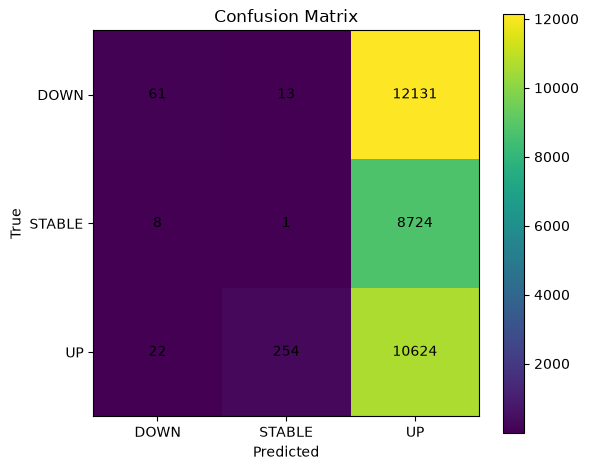

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(
    range(3),
    class_names
)

plt.yticks(
    range(3),
    class_names
)

plt.xlabel("Predicted")

plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

## Observation

The QuantFormer multimodal model has been evaluated on the
complete FI-2010 test dataset.

The evaluation includes:

- Overall Accuracy
- Precision
- Recall
- F1-score
- Per-class performance
- Confusion Matrix

These metrics provide a comprehensive assessment of the
classification capability of the multimodal architecture and
will be used in the project report and performance analysis.

In [115]:
from sklearn.metrics import accuracy_score, classification_report

model.eval()

tft_predictions = []
tft_labels = []

with torch.no_grad():

    for features, labels in test_loader:

        features = features.to(DEVICE)

        logits, _, _ = model(features)

        preds = torch.argmax(logits, dim=1)

        tft_predictions.extend(preds.cpu().numpy())
        tft_labels.extend(labels.numpy())

tft_accuracy = accuracy_score(
    tft_labels,
    tft_predictions
)

print("="*60)
print("TFT Accuracy")
print("="*60)
print(f"Accuracy : {tft_accuracy:.4f}")

print()

print(
    classification_report(
        tft_labels,
        tft_predictions,
        target_names=["DOWN","STABLE","UP"],
        zero_division=0
    )
)


TFT Accuracy
Accuracy : 0.8451

              precision    recall  f1-score   support

        DOWN       0.85      0.84      0.84     12205
      STABLE       0.87      0.86      0.87      8733
          UP       0.82      0.84      0.83     10900

    accuracy                           0.85     31838
   macro avg       0.85      0.85      0.85     31838
weighted avg       0.85      0.85      0.85     31838

